In [1]:
fig_num = 5 # change this to the figure number
analysis_name = "mpfc_dynamic_decoding" # change this to the subfolder it should save to

In [2]:
%load_ext autoreload
%autoreload 2

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "9"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

# Define Data Files/Paths
subject = "wilbur"
date = "20210406"
file_name = subject + date
nwb_file_name = file_name + "_.nwb"

from spyglass.decoding.v1.c3po import Model
import matplotlib.pyplot as plt

if date == "20210404":
    marks_group_name = "mpfc1"
else:
    marks_group_name = "mpfc"

marks_group_name = "mpfc_HYBRID"

model_key = {
    "nwb_file_name": nwb_file_name,
    "marks_group_name": marks_group_name,
    "training_params_name":"wilbur_post_fix"
}
analysis = (Model() & model_key).fetch_c3po_analysis(model_key, checkpoint=6)


from c3po.analysis.analysis import figure_directory
from pathlib import Path
first_epochs = False
fig_dir = Path(figure_directory) / f"Fig{fig_num}/{analysis_name}"/f"{subject}_{date}_{marks_group_name}"
if first_epochs:
    fig_dir = fig_dir / f"first_{first_epochs}_epochs"
fig_dir.mkdir(parents=True, exist_ok=True)

/home/sambray/.local/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82
[2026-09-18 10:15:35,442][INFO]: DataJoint 0.14.9 connected to sambray@lmf-db.cin.ucsf.edu:3306

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python

x shape (1, 34)
x shape (1, 32)


2026-09-18 10:15:53.895253: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-09-18 10:15:55.388771: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-09-18 10:15:56.916964: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
[2026-09-18 10:16:13,380][WARNING]: Skipped checksum for file

In [3]:
from spyglass.common import IntervalList
interval_query = IntervalList & (Model & model_key).proj(interval_list_name="training_interval_name")
run_epochs = interval_query.fetch1("valid_times")

if first_epochs:
    run_epochs = run_epochs[:first_epochs]
analysis.fit_context_pca(fit_intervals = run_epochs)

t_interp = [np.arange(start, end, 0.001) for start, end in run_epochs]
t_interp = np.concatenate(t_interp)
t_interp.shape
analysis.interpolate_context(t_interp)
analysis.embed_context_pca()

# Load Data

### Trial and decoding dataframes

In [4]:
from utils.load_mpfc_data import fetch_behavioral_data, fetch_dio_times, fetch_decoding_df

behave_df_set = fetch_behavioral_data(nwb_file_name)
trial_df = behave_df_set["trial_df"]
alison_df = behave_df_set["alison_df"]

dio_intervals = fetch_dio_times(nwb_file_name)
all_pump_intervals = dio_intervals["all_pump_intervals"]
all_poke_intervals = dio_intervals["all_poke_intervals"]

decoding_df = fetch_decoding_df(nwb_file_name)


[10:20:31][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: fetch_nwb (helper function)
	Use instead: table.fetch_nwb() method (logic integrated into FetchMixin)
[10:20:31][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: get_nwb_table
	Use instead: FetchMixin.fetch_nwb() (logic integrated into mixin)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older 

### Position Data

In [5]:
# =========================================================
# POSITION / SPEED
# =========================================================
from spyglass.common import IntervalPositionInfo
from c3po.analysis.analysis import interval_list_contains_ind
key = {"nwb_file_name": nwb_file_name}

pos_key = {
    "nwb_file_name": nwb_file_name,
    # "interval_list_name": "pos 1 valid times",
    "position_info_param_name": "default",
}
query = IntervalPositionInfo & pos_key
pos_df = []
st_times = []
for k in query.fetch("KEY"):
    print(k)
    pos_df.append((IntervalPositionInfo & k).fetch1_dataframe())
    st_times.append(pos_df[-1].index.values[0])
st_times = np.array(st_times)
ind = np.argsort(st_times)
pos_df = [pos_df[i] for i in ind]
pos_df = pd.concat(pos_df)


{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 0 valid times'}


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 1 valid times'}


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 10 valid times'}


...

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 8 valid times'}


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 9 valid times'}


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


### Sorted Spikes

In [9]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

key = {"nwb_file_name": nwb_file_name}
spikes_query = SortedSpikesGroup() & key
spikes_key = spikes_query.fetch1("KEY")
spikes = (spikes_query).fetch_spike_data(spikes_key)

[10:22:44][WARNING] Spyglass: Missing code for CurationV2


### Hippocampal ripples (Not populated for all days)

In [10]:
from spyglass.ripple.v1 import RippleTimesV1

sleep_ripp_df = (
    RippleTimesV1() & key & "target_interval_list_name LIKE '%_s'"
).fetch_dataframe()
if len(sleep_ripp_df) > 0:
    sleep_ripp_df = pd.concat(sleep_ripp_df)

run_ripp_df = (
    RippleTimesV1() & key & "target_interval_list_name LIKE '%_r%'"
).fetch_dataframe()

if len(run_ripp_df) > 0:
    run_ripp_df = pd.concat(run_ripp_df)

# Decoding

## 1 Feature

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import zscore
from tqdm import tqdm

In [106]:
_df = trial_df.copy()
_df = _df[_df.n_pre_switch > 0]
_df = _df[_df.n_post_switch > 0]
_df = _df[_df.prev_trial_reward==0]
# _df = _df[_df.epoch < 6]

decode_feature = "prev_trial_reward"
decode_feature = "Q_leaf_A_update"
step_size = 0.1
window_size = 0.25

# decode_feature = "prev_trial_reward"
# decode_feature = "n_post_switch"
step_size = 0.03
window_size = .05


mark_list = [ "run_start", "t_choice", "t_poke", ]
offset_list = [ -1, 1.25, 2.5, ]
range_list = [ (-1, 1.5), (-0.5, 0.5), (-0.5, 1)]


_df = _df[~np.isnan(_df[decode_feature].values)]
results = {m:[] for m in mark_list}
r2 = {m:[] for m in mark_list}
for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    for window_shift in tqdm(np.arange(range_val[0], range_val[1]+1e-4, step_size)):
        vals = _df[mark].values + window_shift
        ind_vals = np.logical_and(vals > analysis.t_interp[0], vals < analysis.t_interp[-1])
        _df_i = _df[ind_vals]


        marks_i = _df_i[mark].values + window_shift
        context_i = analysis.alligned_response(marks_i, (-window_size, window_size), pca=True).mean(axis=1)
        # context_i = zscore(context_i, axis=0)

        decode_ = LinearRegression()
        y = _df_i[decode_feature].values
        y = zscore(y)
        decode = decode_.fit(context_i, y)
        coef_i = decode.coef_
        y_pred = decode.predict(context_i)
        r2_i = r2_score(y, y_pred)
        results[mark].append(coef_i)
        r2[mark].append(r2_i)
        # break




100%|██████████| 51/51 [00:04<00:00, 12.58it/s]


Text(0, 0.5, '$R^2$')

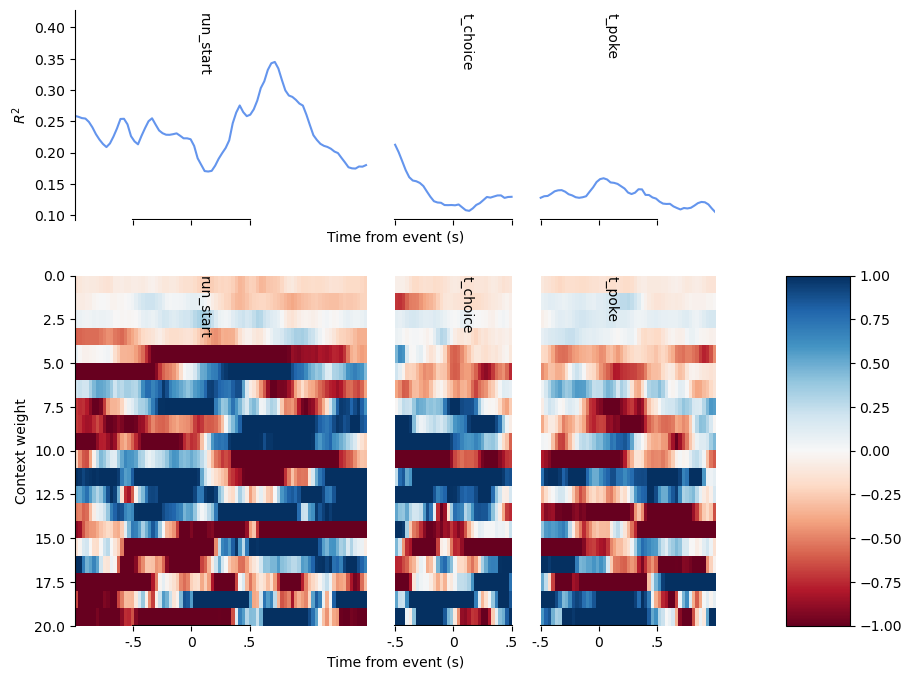

In [108]:
fig, ax = plt.subplots(figsize=(10, 8),nrows=2,height_ratios=[3,5],sharex="col",
                       ncols=2, width_ratios=[10,1])
r2_ax = ax[0,0]
coef_ax = ax[1,0]
cbar_ax = ax[1,1]
ax[0,1].axis("off")

min_val = 0
max_val = 0
v_rng = 1
for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    r2_i = np.array(r2[mark])
    results_i = np.array(results[mark])

    t_plot = np.linspace(range_val[0], range_val[1], len(r2_i))+offset
    min_val = min(min_val, t_plot.min())
    max_val = max(max_val, t_plot.max())

    r2_ax.plot(t_plot, r2_i, label=mark, color="cornflowerblue")

    cb = coef_ax.imshow(results_i.T, aspect="auto", extent=[t_plot[0], t_plot[-1], results_i.shape[1],0], origin="upper",
                        cmap = "RdBu", vmin=-v_rng, vmax=v_rng, )

plt.colorbar(cb, cax=cbar_ax)
coef_ax.set_xlim(min_val, max_val)


for a in ax[:,0]:
    ylim = a.get_ylim()
    ylim_top = ylim[1] * 1.2
    a.set_ylim(ylim[0], ylim_top)

    for mark, offset in zip(mark_list, offset_list):
        a.text(offset + 0.05, ylim_top * 0.99, mark, ha="left", va="top", rotation=-90)
        # a.

    ticks = []
    labels = []
    for mark, offset in zip(mark_list, offset_list):
        xx = np.array([-0.5, 0, 0.5])
        ticks.append(xx + offset)
        labels.append(["-.5", "0", ".5"])
        a.plot(xx + offset, [ylim[0]] * len(xx), color="k")
    ticks = np.concatenate(ticks)
    labels = np.concatenate(labels)
    a.set_xticks(ticks, labels)
    a.set_xlabel("Time from event (s)")

    a.spines[["top", "right", "bottom"]].set_visible(False)
    # fig.legend(loc="outside right upper", fontsize="small", title=condition_feature)

    a.set_ylabel("Context weight")
    # fig.suptitle(f"Neuron {neurons_to_plot[pc]} (PC angle = {z_angle[neurons_to_plot[pc]]:.2f})")

r2_ax.set_ylabel("$R^2$")

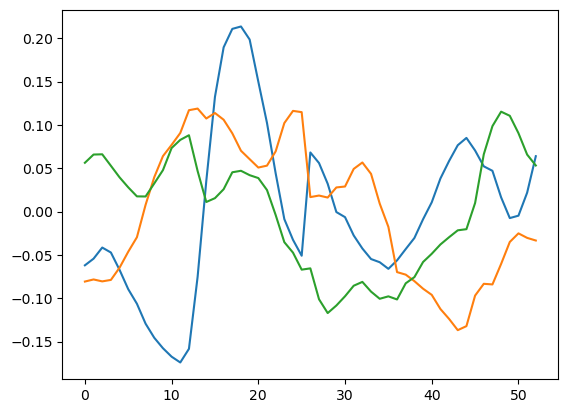

In [35]:
all_results = np.concatenate([np.array(results[m]) for m in mark_list], axis=0)
all_results.shape
from sklearn.decomposition import PCA
code_pca = PCA(n_components=3)
code_pca.fit(all_results)
qq = code_pca.transform(all_results)

plt.plot(qq)


In [39]:
decayed_factor = .8 ** trial_df.n_post_switch.values
trial_df["decayed_factor"] = decayed_factor



In [36]:
trial_df.n_post_switch.values[0]

np.int64(-1)

## Multiple Features

In [136]:
_df = trial_df.copy()
_df = _df[_df.n_pre_switch > 0]
_df = _df[_df.n_post_switch > 0]
# _df = _df[_df.prev_trial_reward==0]
# _df = _df[_df.epoch < 6]

decode_df_list = [_df, _df, _df[_df.prev_trial_reward==0], _df[_df.prev_trial_reward==1]]
decode_df_tags = ["(all)", "(all)", "(non-rewarded)", "(rewarded)"]

decode_feature_list = [ "prev_trial_reward","Q_leaf_A_update", "Q_leaf_A_update", "Q_leaf_A_update"]
# decode_feature_list = [ "prev_trial_reward","n_post_switch", "n_post_switch", "n_post_switch"]
# decode_feature_list = ["prev_trial_reward","Qdep_leaf_A_update", "Qdep_leaf_A_update", "Qdep_leaf_A_update"]
# decode_feature_list = ["prev_trial_reward","Qdep_leaf_A", "Qdep_leaf_A", "Qdep_leaf_A"]
# decode_feature_list = ["prev_trial_reward","decayed_factor", "decayed_factor", "decayed_factor"]


# step_size = 0.1
# window_size = 0.25
step_size = 0.02
window_size = 0.05


mark_list = [ "run_start", "t_choice", "t_poke", ]
offset_list = [ -1, .75, 2., ]
range_list = [ (-1, 1), (-0.5, 0.5), (-0.5, 1)]



decode_df_list = [df[~np.isnan(df[decode_feature_list].values).any(axis=1)] for df in decode_df_list]
results = {m:[] for m in mark_list}
r2 = {m:[] for m in mark_list}
for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    for window_shift in tqdm(np.arange(range_val[0], range_val[1]+1e-4, step_size)):
        results_window = []
        r2_window = []
        for _df, decode_feature, tag in zip(decode_df_list, decode_feature_list, decode_df_tags):

            vals = _df[mark].values + window_shift
            ind_vals = np.logical_and(vals > analysis.t_interp[0], vals < analysis.t_interp[-1])
            _df_i = _df[ind_vals]


            marks_i = _df_i[mark].values + window_shift
            context_i = analysis.alligned_response(marks_i, (-window_size, window_size), pca=True).mean(axis=1)
            context_i = zscore(context_i, axis=0)

            decode_ = LinearRegression()
            y = _df_i[decode_feature].values
            y = zscore(y)
            decode = decode_.fit(context_i, y)
            coef_i = decode.coef_
            y_pred = decode.predict(context_i)
            # r2_i = [r2_score(y[:, j], y_pred[:, j]) for j in range(y.shape[1])]
            r2_i = r2_score(y, y_pred)
            results_window.append(coef_i)
            r2_window.append(r2_i)
        results[mark].append(results_window)
        r2[mark].append(r2_window)
        # break




100%|██████████| 76/76 [00:25<00:00,  2.99it/s]


/tmp/ipykernel_1996880/1857045193.py:25: UserWarning: Adding colorbar to a different Figure <Figure size 1000x800 with 4 Axes> than <Figure size 500x250 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(cb, cax=cbar_ax)


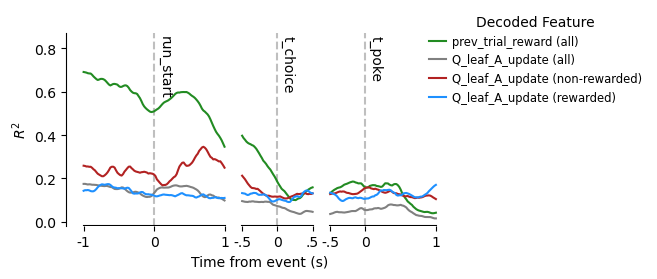

In [137]:
color_list = ["forestgreen", "grey", "firebrick", "dodgerblue"]

fig, ax = plt.subplots(figsize=(5, 2.5),nrows=1,sharex="col",
                       ncols=1)
r2_ax = ax

min_val = 0
max_val = 0

for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    r2_i = np.array(r2[mark])
    results_i = np.array(results[mark])

    t_plot = np.linspace(range_val[0], range_val[1], len(r2_i))+offset
    min_val = min(min_val, t_plot.min())
    max_val = max(max_val, t_plot.max())

    for j in range(r2_i.shape[1]):
        label=f"{decode_feature_list[j]} {decode_df_tags[j]}" if mark==mark_list[0] else None
        r2_ax.plot(t_plot, r2_i[:, j],color=color_list[j], label = label)
    r2_ax.axvline(offset, color="grey", linestyle="--", zorder=-1, alpha=0.5)
    # cb = coef_ax.imshow(results_i.T, aspect="auto", extent=[t_plot[0], t_plot[-1], results_i.shape[1],0], origin="upper",
    #                     cmap = "RdBu", vmin=-v_rng, vmax=v_rng, )

plt.colorbar(cb, cax=cbar_ax)
coef_ax.set_xlim(min_val, max_val)


for a in [ax]:
    ylim = a.get_ylim()
    ylim_top = ylim[1] * 1.2
    a.set_ylim(ylim[0], ylim_top)

    for mark, offset in zip(mark_list, offset_list):
        a.text(offset + 0.05, ylim_top * 0.99, mark, ha="left", va="top", rotation=-90)
        # a.

    ticks = []
    labels = []
    for mark, offset, rng in zip(mark_list, offset_list, range_list):
        lo = -1 if rng[0] < -.75 else rng[0]
        hi = 1 if rng[1] > 1 else rng[1]
        lo_txt = "-.5" if lo == -0.5 else "-1"
        hi_txt = ".5" if hi == 0.5 else "1"

        xx = np.array([lo, 0, hi])
        ticks.append(xx + offset)
        labels.append([lo_txt, "0", hi_txt])
        a.plot(xx + offset, [ylim[0]] * len(xx), color="k")
    ticks = np.concatenate(ticks)
    labels = np.concatenate(labels)
    a.set_xticks(ticks, labels)
    a.set_xlabel("Time from event (s)")

    a.spines[["top", "right", "bottom"]].set_visible(False)
    # fig.legend(loc="outside right upper", fontsize="small", title=condition_feature)

    a.set_ylabel("Firing Rate (Hz)")
    # fig.suptitle(f"Neuron {neurons_to_plot[pc]} (PC angle = {z_angle[neurons_to_plot[pc]]:.2f})")

r2_ax.set_ylabel("$R^2$")
fig.legend(loc="upper right", fontsize="small", title="Decoded Feature",bbox_to_anchor=(1.3, 1),
           frameon=False, borderpad=0.5, labelspacing=0.5, handletextpad=0.5, handlelength=1.5)


# fig.savefig(fig_dir / f"dynamic_decoding_value_updates.svg", bbox_inches="tight")
# fig.savefig(fig_dir / f"dynamic_decoding_n_post_switch.svg", bbox_inches="tight")

# Multiple features, Cross-validated

In [ ]:
n_fold_cross = 5
splits_to_sample = 100

_df = trial_df.copy()
_df = _df[_df.n_pre_switch > 0]
_df = _df[_df.n_post_switch > 0]
# _df = _df[_df.prev_trial_reward==0]
# _df = _df[_df.epoch < 6]

decode_df_list = [_df, _df, _df[_df.prev_trial_reward==0], _df[_df.prev_trial_reward==1]]
decode_df_tags = ["(all)", "(all)", "(non-rewarded)", "(rewarded)"]

decode_feature_list = [ "prev_trial_reward","Q_leaf_A_update", "Q_leaf_A_update", "Q_leaf_A_update"]
# decode_feature_list = [ "prev_trial_reward","n_post_switch", "n_post_switch", "n_post_switch"]
# decode_feature_list = ["prev_trial_reward","Qdep_leaf_A_update", "Qdep_leaf_A_update", "Qdep_leaf_A_update"]
# decode_feature_list = ["prev_trial_reward","Qdep_leaf_A", "Qdep_leaf_A", "Qdep_leaf_A"]
# decode_feature_list = ["prev_trial_reward","decayed_factor", "decayed_factor", "decayed_factor"]


# step_size = 0.1
# window_size = 0.25
step_size = 0.02
window_size = 0.05


mark_list = [ "run_start", "t_choice", "t_poke", ]
offset_list = [ -1, .75, 2., ]
range_list = [ (-1, 1), (-0.5, 0.5), (-0.5, 1)]



decode_df_list = [df[~np.isnan(df[decode_feature_list].values).any(axis=1)] for df in decode_df_list]
results = {m:[] for m in mark_list}
r2 = {m:[] for m in mark_list}
for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    for window_shift in tqdm(np.arange(range_val[0], range_val[1]+1e-4, step_size)):


        results_window = []
        r2_window = []
        for _df, decode_feature, tag in zip(decode_df_list, decode_feature_list, decode_df_tags):

            vals = _df[mark].values + window_shift
            ind_vals = np.logical_and(vals > analysis.t_interp[0], vals < analysis.t_interp[-1])
            _df_i = _df[ind_vals]


            marks_i = _df_i[mark].values + window_shift
            context_i = analysis.alligned_response(marks_i, (-window_size, window_size), pca=True).mean(axis=1)
            context_i = zscore(context_i, axis=0)


            ind_all = np.arange(len(context_i))
            ind_all = np.random.permutation(ind_all)
            if splits_to_sample is None:
                ind_folds = np.array_split(ind_all, n_fold_cross)
            else:
                ind_folds = [np.random.choice(ind_all, size=len(ind_all)//n_fold_cross, replace=False) for _ in range(splits_to_sample)]
            r2_i = []
            for fold in range(len(ind_folds)):
                ind_test = ind_folds[fold]
                # ind_train = np.concatenate([ind_folds[i] for i in range(n_fold_cross) if i != fold])
                ind_train = ind_all[~np.isin(ind_all, ind_test)]
                context_train = context_i[ind_train]
                context_test = context_i[ind_test]
                y_train = _df_i[decode_feature].values[ind_train]
                y_test = _df_i[decode_feature].values[ind_test]

                decode_ = LinearRegression()

                decode = decode_.fit(context_train, y_train)
                # coef_i = decode.coef_
                y_pred = decode.predict(context_test)
                # r2_i = [r2_score(y[:, j], y_pred[:, j]) for j in range(y.shape[1])]
                r2_i.append(r2_score(y_test, y_pred))
            # results_window.append(coef_i)
            r2_window.append(np.array(r2_i))
        # results[mark].append(results_window)
        r2[mark].append(r2_window)
        # break




100%|██████████| 76/76 [00:58<00:00,  1.31it/s]


/tmp/ipykernel_1996880/2400861123.py:32: UserWarning: Adding colorbar to a different Figure <Figure size 1000x800 with 4 Axes> than <Figure size 325x150 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(cb, cax=cbar_ax)


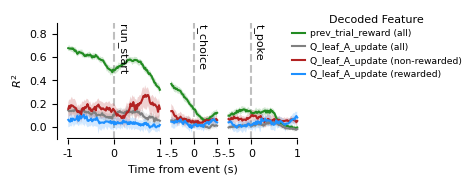

In [ ]:
color_list = ["forestgreen", "grey", "firebrick", "dodgerblue"]

fig, ax = plt.subplots(figsize=(3.25, 1.5),nrows=1,sharex="col",
                       ncols=1)
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 8
r2_ax = ax

min_val = 0
max_val = 0

for mark, offset, range_val in zip(mark_list, offset_list, range_list):
    r2_i_all = np.array(r2[mark])
    r2_i = np.median(r2_i_all, axis=2)
    r2_i_lo = np.percentile(r2_i_all, 25, axis=2)
    r2_i_hi = np.percentile(r2_i_all, 75, axis=2)

    results_i = np.array(results[mark])

    t_plot = np.linspace(range_val[0], range_val[1], len(r2_i))+offset
    min_val = min(min_val, t_plot.min())
    max_val = max(max_val, t_plot.max())

    for j in range(r2_i.shape[1]):
        label=f"{decode_feature_list[j]} {decode_df_tags[j]}" if mark==mark_list[0] else None
        r2_ax.plot(t_plot, r2_i[:, j],color=color_list[j], label = label)
        r2_ax.fill_between(t_plot, r2_i_lo[:, j], r2_i_hi[:, j], facecolor=color_list[j], alpha=0.2)
    r2_ax.axvline(offset, color="grey", linestyle="--", zorder=-1, alpha=0.5)
    # cb = coef_ax.imshow(results_i.T, aspect="auto", extent=[t_plot[0], t_plot[-1], results_i.shape[1],0], origin="upper",
    #                     cmap = "RdBu", vmin=-v_rng, vmax=v_rng, )

plt.colorbar(cb, cax=cbar_ax)
coef_ax.set_xlim(min_val, max_val)


for a in [ax]:
    ylim = a.get_ylim()
    ylim_top = ylim[1] * 1.2
    a.set_ylim(ylim[0], ylim_top)

    for mark, offset in zip(mark_list, offset_list):
        a.text(offset + 0.05, ylim_top * 0.99, mark, ha="left", va="top", rotation=-90)
        # a.

    ticks = []
    labels = []
    for mark, offset, rng in zip(mark_list, offset_list, range_list):
        lo = -1 if rng[0] < -.75 else rng[0]
        hi = 1 if rng[1] > 1 else rng[1]
        lo_txt = "-.5" if lo == -0.5 else "-1"
        hi_txt = ".5" if hi == 0.5 else "1"

        xx = np.array([lo, 0, hi])
        ticks.append(xx + offset)
        labels.append([lo_txt, "0", hi_txt])
        a.plot(xx + offset, [ylim[0]] * len(xx), color="k")
    ticks = np.concatenate(ticks)
    labels = np.concatenate(labels)
    a.set_xticks(ticks, labels)
    a.set_xlabel("Time from event (s)")

    a.spines[["top", "right", "bottom"]].set_visible(False)
    # fig.legend(loc="outside right upper", fontsize="small", title=condition_feature)

    a.set_ylabel("Firing Rate (Hz)")
    # fig.suptitle(f"Neuron {neurons_to_plot[pc]} (PC angle = {z_angle[neurons_to_plot[pc]]:.2f})")

r2_ax.set_ylabel("$R^2$")
fig.legend(loc="upper right", fontsize="small", title="Decoded Feature",bbox_to_anchor=(1.4, 1),
           frameon=False, borderpad=0.5, labelspacing=0.5, handletextpad=0.5, handlelength=1.5)



fig.savefig(fig_dir / f"dynamic_decoding_value_updates_CROSSVAL.svg", bbox_inches="tight")
# fig.savefig(fig_dir / f"dynamic_decoding_n_post_switch.svg", bbox_inches="tight")

In [126]:
np.random.permutation(np.arange(10))

array([8, 6, 2, 9, 1, 3, 4, 0, 5, 7])

In [127]:
np.array_split(np.arange(10), 3)

[array([0, 1, 2, 3]), array([4, 5, 6]), array([7, 8, 9])]

In [ ]:
_df = trial_df.copy()
_df = _df[_df.n_pre_switch > 0]
_df = _df[_df.prev_trial_reward==0]

mark = "run_start"
feature = "Q_leaf_A_update"
window = (.5,1)

_df = _df[~np.isnan(_df[decode_feature].values)]
counts = np.zeros((len(_df), len(spikes)))
for i, m in enumerate(_df[mark].values):
    for j, s in enumerate(spikes):
        ind_st = np.searchsorted(s, m + window[0])
        ind_end = np.searchsorted(s[ind_st:], m + window[1])
        counts[i, j] = ind_end

vals = _df[feature].values
r2_spiking = np.zeros((len(spikes),))
for j in range(len(spikes)):
    y = counts[:, j]
    if sum(y) == 0:
        r2_spiking[j] = np.nan
        continue
    y = zscore(y)
    # r2_spiking[j] = r2_score(y, zscore(vals))
    r2_spiking[j] = np.corrcoef(y, zscore(vals))[0,1]


ind_sig = np.where(np.abs(r2_spiking) > 0.2)[0]
ind_sig

array([ 42,  49,  66,  78,  85, 101, 105, 115, 132, 137, 141, 142, 145,
       149, 159, 181, 196, 200, 206, 223, 237, 246, 253, 258, 264, 267,
       270, 279, 282, 288, 292, 320, 322, 323, 326, 330, 351, 355, 359,
       360, 363, 405, 425, 428, 443, 451, 453, 457, 467, 468, 484, 488])

# Reward vs no Reward samples

# Spiking

/tmp/ipykernel_1996880/3715897212.py:39: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(2, 3))


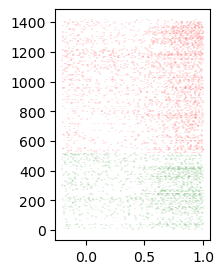

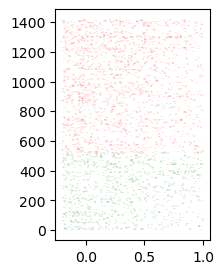

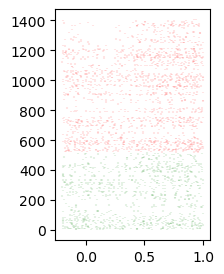

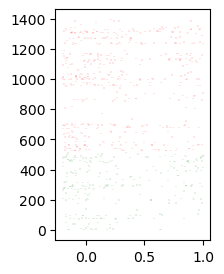

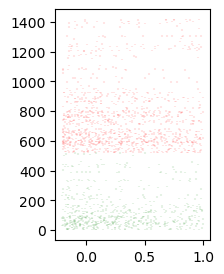

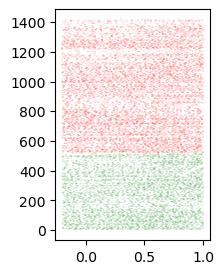

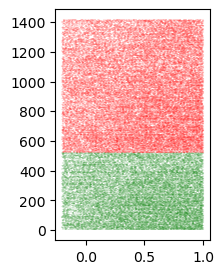

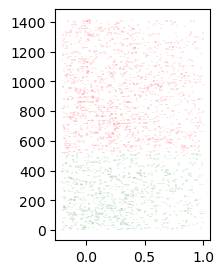

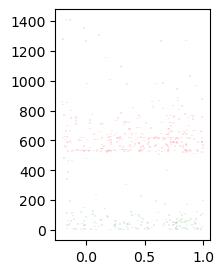

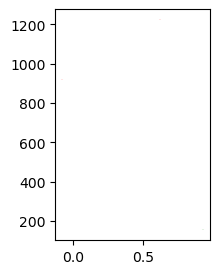

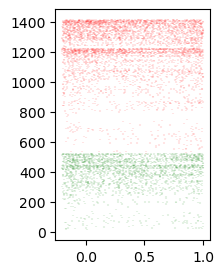

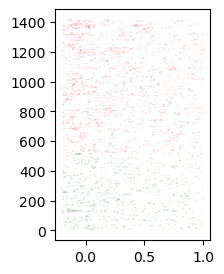

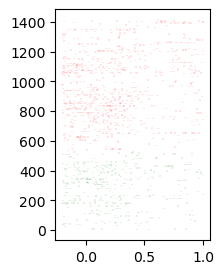

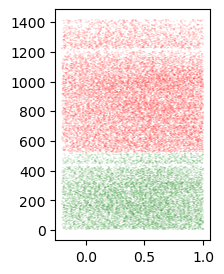

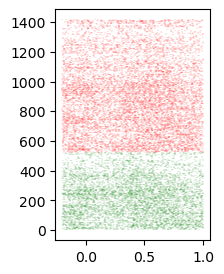

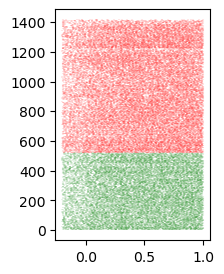

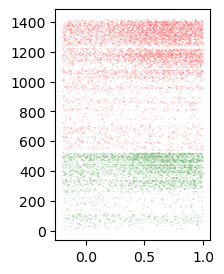

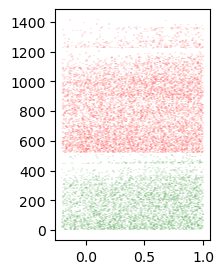

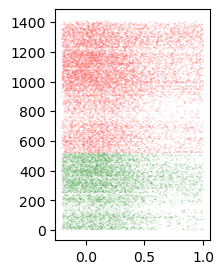

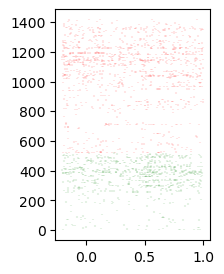

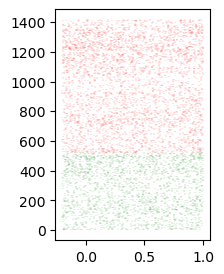

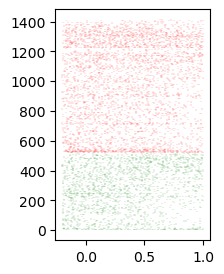

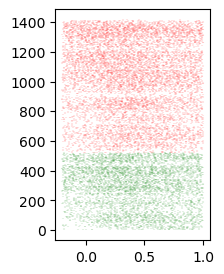

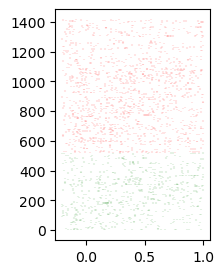

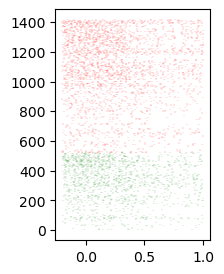

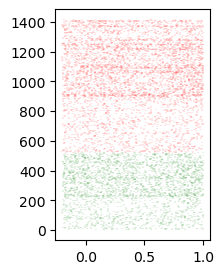

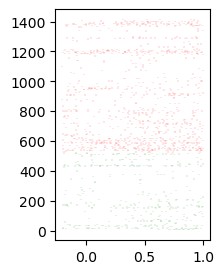

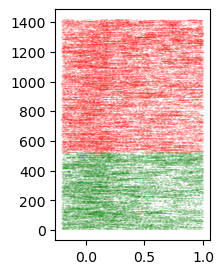

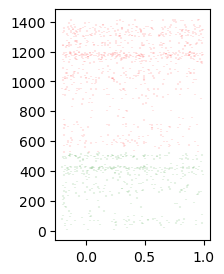

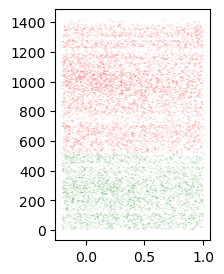

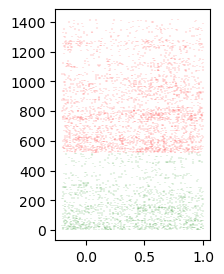

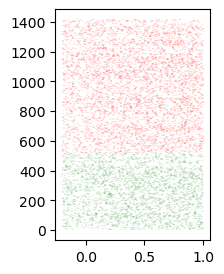

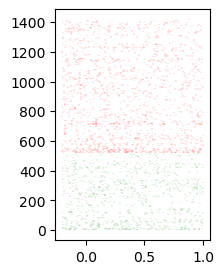

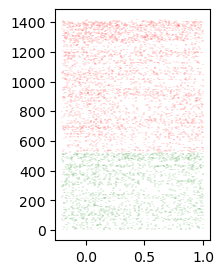

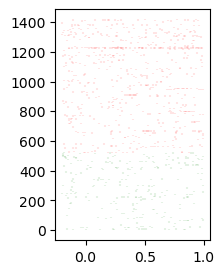

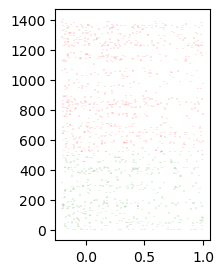

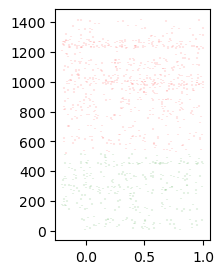

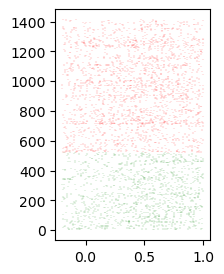

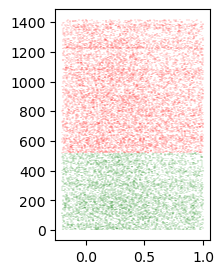

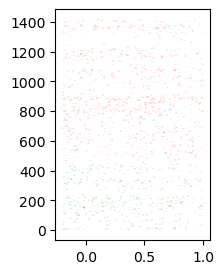

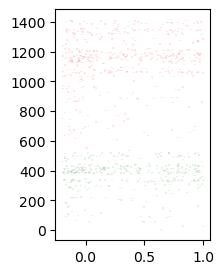

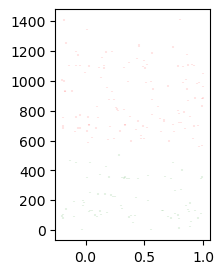

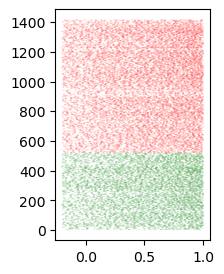

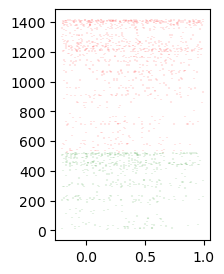

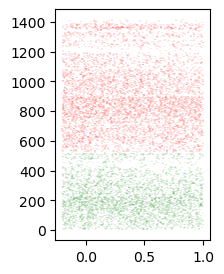

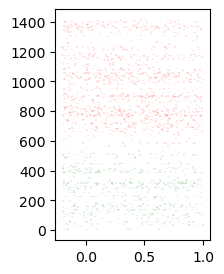

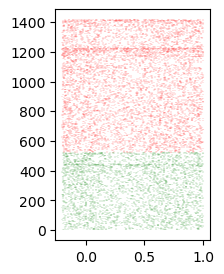

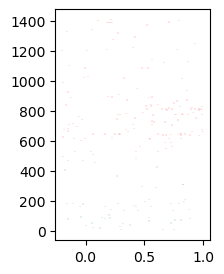

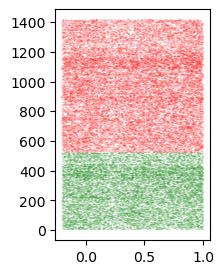

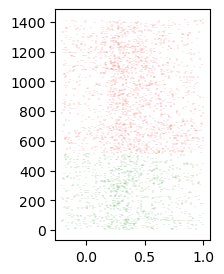

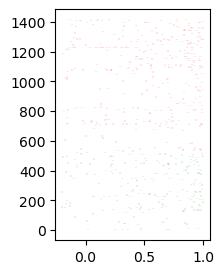

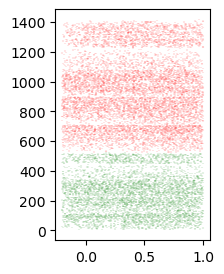

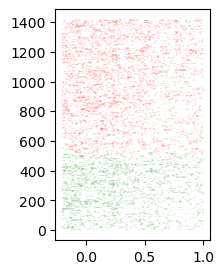

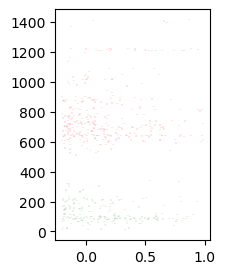

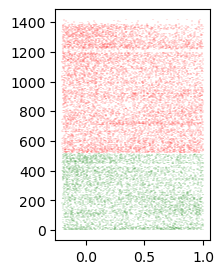

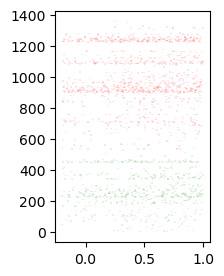

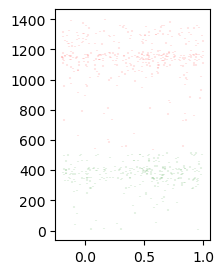

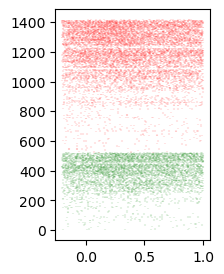

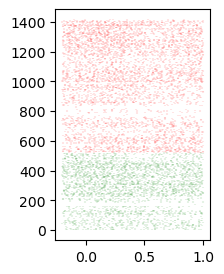

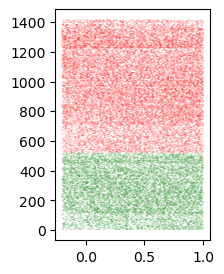

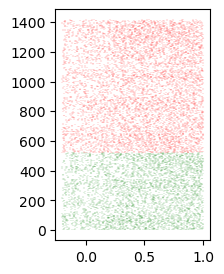

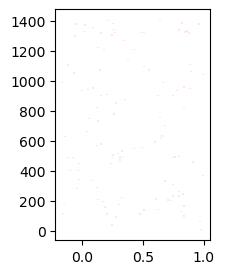

In [ ]:
z_pca = analysis.params['params']['embedding']['encoder']['sorted_encoder']['encoder_matrix'] @ analysis.pca.components_.T

pc_target = 7

ind_neuron = np.where(np.abs(z_pca[:, pc_target]) > 0.15)[0]

# plt.hist(z_pca[:, pc_target])

mark = "run_start"
window = -.2,1

i_neuron = ind_neuron[3]
for i_neuron in ind_neuron:
    trial_spikes = []
    trial_reward = []

    for t, r in zip(trial_df[mark], trial_df['reward']):
        st = np.digitize(t+window[0],spikes[i_neuron])
        en = st + np.digitize(t+window[1],spikes[i_neuron][st:])
        trial_spikes.append(spikes[i_neuron][st:en] - t)
        trial_reward.append(r)


    xx = []
    yy = []
    cc = []
    ind = np.where(np.array(trial_reward) == 1)[0]
    for i in ind:
        xx.append(trial_spikes[i])
        yy.append(np.ones_like(trial_spikes[i]) * len(xx))
        cc.append(["green"]*len(trial_spikes[i]))
    ind = np.where(np.array(trial_reward) == 0)[0]
    for i in ind:

        xx.append(trial_spikes[i])
        yy.append(np.ones_like(trial_spikes[i]) * len(xx))
        cc.append(["red"]*len(trial_spikes[i]))

    fig = plt.figure(figsize=(2, 3))
    plt.scatter(np.concatenate(xx), np.concatenate(yy), c=np.concatenate(cc), s=1, alpha = .1,marker = "|")

(array([ 2.,  0.,  7., 17., 16., 28., 29., 52., 60., 61., 56., 52., 44.,
        31., 19., 14.,  4.,  3.,  0.,  2.]),
 array([-0.29070514, -0.26088753, -0.23106992, -0.2012523 , -0.17143469,
        -0.14161707, -0.11179945, -0.08198184, -0.05216423, -0.02234662,
         0.007471  ,  0.03728861,  0.06710625,  0.09692386,  0.12674147,
         0.15655908,  0.18637669,  0.21619433,  0.24601191,  0.27582955,
         0.30564713]),
 <BarContainer object of 20 artists>)

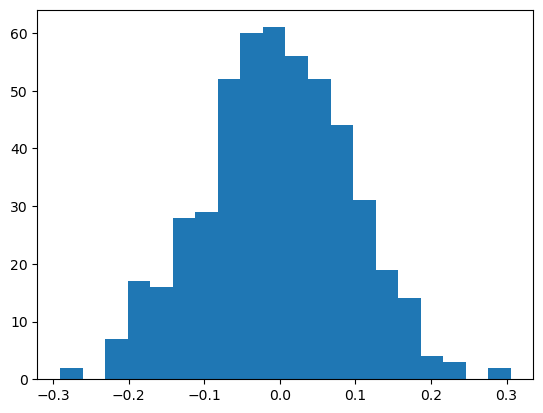

In [73]:
plt.hist(z_pca[:, pc_target], bins=20)

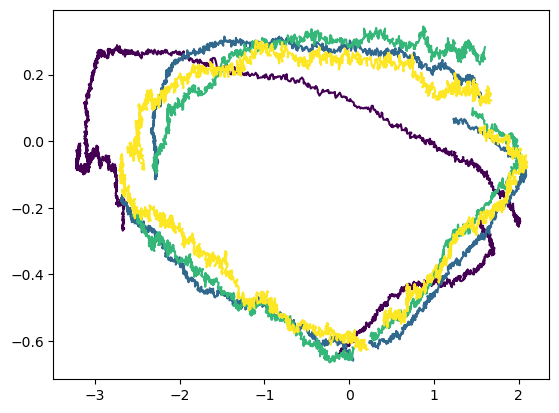

In [ ]:
pc_pair = (1,3)
base_df = trial_df.copy()
# base_df = base_df[base_df.prev_trial_reward==0]
mark_list = [ "run_start", "t_choice", "t_poke", ]
offset_list = [ -1, .75, 2., ]
range_list = [ (-.5, 1), (-0.5, 0.5), (-0.5, .5)]
pre_switch_vals = np.arange(5)
pre_switch_vals = [0,2,4,6]
# pre_switch_vals = [1,3,5,7]
for n_pre_switch in pre_switch_vals:
    _df = base_df.copy()
    _df = _df[_df.n_pre_switch == n_pre_switch]

    color = plt.cm.viridis(n_pre_switch / np.max(pre_switch_vals))
    for mark, offset, range_val in zip(mark_list, offset_list, range_list):
        result = analysis.alligned_response(_df[mark].values, range_val, pca=True)
        mid = np.mean(result, axis=0)
        plt.plot(mid[:,pc_pair[0]], mid[:,pc_pair[1]], color=color)

In [81]:
mid.shape

(1500, 20)